# ORB-Based CBIR

This notebook implements a Content-Based Image Retrieval (CBIR) system
using ORB keypoint descriptors.

Steps:
- Load processed dataset
- Extract ORB descriptors
- Build feature database
- Match query image with dataset images
- Retrieve top similar images

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DATASET_PATH = "processed_dataset"

categories = sorted(os.listdir(DATASET_PATH))
print("Categories:", categories)

Categories: ['ambulance', 'bicycle', 'bus', 'car', 'fire_truck', 'motorcycle', 'tractor', 'truck', 'van']


## ORB Feature Extraction

ORB detects keypoints and computes binary descriptors.
These descriptors can be matched between images using Hamming distance.

In [3]:
# Create ORB object
orb = cv2.ORB_create(nfeatures=1000)

In [4]:
def extract_orb_descriptors(image_path):
    """
    Extract ORB keypoints and descriptors from an image.

    Parameters:
        image_path : str
            Path to input image

    Returns:
        descriptors : numpy array or None
            ORB descriptors
    """
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    keypoints, descriptors = orb.detectAndCompute(image, None)

    return descriptors

## Build Feature Database

For each image in the dataset:
- extract ORB descriptors
- store image path
- store category label

In [5]:
image_paths = []
image_labels = []
descriptor_database = []

for category in categories:
    category_path = os.path.join(DATASET_PATH, category)

    for img_name in os.listdir(category_path):
        img_path = os.path.join(category_path, img_name)
        descriptors = extract_orb_descriptors(img_path)

        # Some images may have no descriptors
        if descriptors is not None:
            image_paths.append(img_path)
            image_labels.append(category)
            descriptor_database.append(descriptors)

print("Total images indexed:", len(image_paths))

Total images indexed: 1800


## Similarity Function

ORB descriptors are matched using Brute-Force Matcher with Hamming distance.

The similarity score is based on the number of good matches:
- more good matches = more similar

In [7]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

def compute_orb_similarity(query_descriptors, train_descriptors):
    """
    Compute similarity score based on ORB descriptor matching.
    
    Parameters:
        query_descriptors : numpy array
        train_descriptors : numpy array
        
    Returns:
        score : float
            Similarity score
    """
    if query_descriptors is None or train_descriptors is None:
        return 0

    matches = bf.match(query_descriptors, train_descriptors)

    if len(matches) == 0:
        return 0

    matches = sorted(matches, key=lambda x: x.distance)

    # Use average of top matches for stronger comparison
    good_matches = [m for m in matches if m.distance < 50]

    return len(good_matches)

## Retrieve Similar Images

In [8]:
def retrieve_similar_images(query_image_path, top_k=5):
    """
    Retrieve top_k similar images using ORB feature matching.
    """
    query_descriptors = extract_orb_descriptors(query_image_path)

    if query_descriptors is None:
        print("Query image could not be loaded or has no descriptors.")
        return []

    results = []

    for i in range(len(image_paths)):
        # Skip the query image itself
        if image_paths[i] == query_image_path:
            continue

        score = compute_orb_similarity(query_descriptors, descriptor_database[i])

        results.append({
            "image_path": image_paths[i],
            "label": image_labels[i],
            "score": score
        })

    # Sort by score from highest to lowest
    results = sorted(results, key=lambda x: x["score"], reverse=True)

    return results[:top_k]

## Test with a Query Image

A query image is selected automatically from one category folder.

In [9]:
category_path = "processed_dataset/car"   # change category if needed
img_name = os.listdir(category_path)[0]

query_image = os.path.join(category_path, img_name)

print("Using query image:", query_image)

results = retrieve_similar_images(query_image, top_k=5)

for i, result in enumerate(results, 1):
    print(f"Rank {i}: {result['label']} | Score = {result['score']}")

Using query image: processed_dataset/car\1007.jpg
Rank 1: car | Score = 724
Rank 2: car | Score = 57
Rank 3: bus | Score = 41
Rank 4: van | Score = 41
Rank 5: bus | Score = 40


## Display Query Image and Retrieved Results

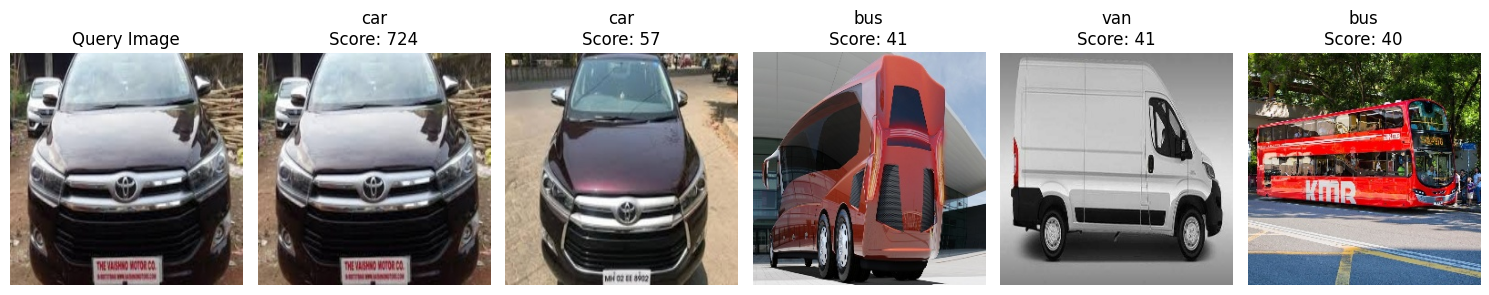

In [10]:
def display_results(query_image_path, results):
    plt.figure(figsize=(15, 4))

    # Show query image
    query_img = cv2.imread(query_image_path)
    query_img = cv2.cvtColor(query_img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(query_img)
    plt.title("Query Image")
    plt.axis("off")

    # Show retrieved images
    for i, result in enumerate(results, start=2):
        img = cv2.imread(result["image_path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(results) + 1, i)
        plt.imshow(img)
        plt.title(f"{result['label']}\nScore: {result['score']}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

display_results(query_image, results)

## Precision@5 Evaluation

In [11]:
def precision_at_k(query_image_path, results, k=5):
    query_label = os.path.basename(os.path.dirname(query_image_path))
    correct = sum(1 for r in results[:k] if r["label"] == query_label)
    return correct / k

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

Precision@5: 0.40


## Test Another Category

ORB often works better for categories with local shape details and keypoints.
Examples:
- processed_dataset/buses
- processed_dataset/dinosaurs
- processed_dataset/buildings

Using query image: processed_dataset/motorcycle\0e277122-ac78-4f73-a205-d7dd189e7dbb.jpg


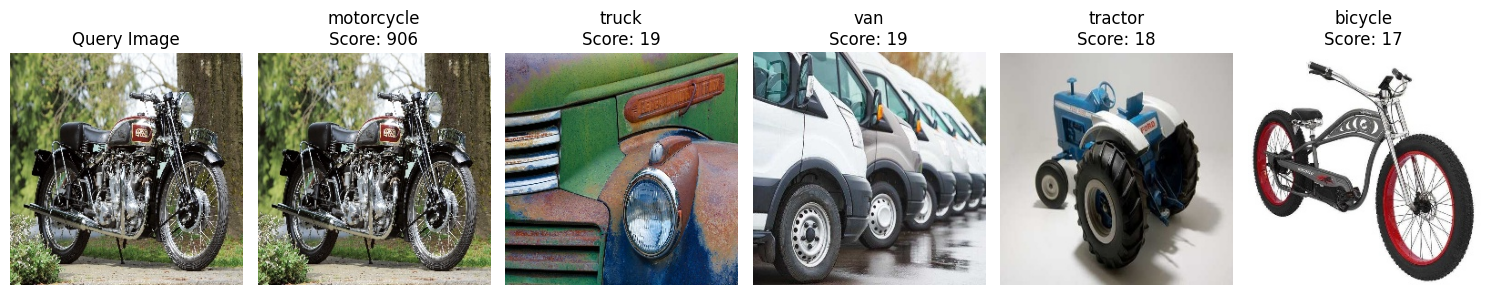

Precision@5: 0.20


In [12]:
category_path = "processed_dataset/motorcycle"
img_name = os.listdir(category_path)[6]
query_image = os.path.join(category_path, img_name)

print("Using query image:", query_image)

results = retrieve_similar_images(query_image, top_k=5)
display_results(query_image, results)

p_at_5 = precision_at_k(query_image, results, k=5)
print(f"Precision@5: {p_at_5:.2f}")

## Summary

This notebook builds a CBIR system using ORB descriptors.

ORB is useful for matching local visual patterns and keypoints.
It is often more effective for images with distinctive structures and details.

However, it may perform less well on images with weak keypoints
or smooth regions with limited local features.